Задача
Необходимо определить:
1. Какие наборы метрик для оценки эффективности работы кофеен Вы можете предложить?
2. Какие из них рекомендуете выбрать как основные, чтобы дать оценку этому продукту? Почему?
3. Разметка каких событий Вам понадобится?
4. Какую информацию необходимо передавать в событиях?

Какие наборы метрик для оценки эффективности продаж Вы можете предложить?
1. Average revenue per user — средний доход с пользователя. С помощью этой метрики можно оценить всю выручку, которую бизнес заработал с одного пользователя за определенный период.
2. Average order value — это сумма, которую в среднем тратят клиенты в магазине. Рассчитывается как отношение выручки к количеству чеков или заказов за определенный период времени.
3. Monthly recurring revenue —  метрика, которая отображает стабильную ежемесячную прибыль бизнеса.
4. Purchase Frequency — эта метрика показывает, как часто клиент совершает повторную покупку.
5. Most profitable product - эта метрика показывает, какой товар является самым прибыльным.

Какие из них рекомендуете выбрать как основные, чтобы дать оценку этому продукту? Почему?
К сожалению, некоторые указанные выше метрики, а также более сложные метрики - реализовать с этим набором данных не получится. Не хватает различных данных, например client_id, который хранил бы данные о клиентах (например: карточки для накопления кэшбека помогли бы с этим). 
Поэтому в данном случае, рекомендуется использовать такие метрики как:
1. ARPU
2. AOV
3. MRR
4. MPP

Разметка каких событий вам понадобится?
1. Идентификатор транзакции.
Сопоставление событий с конкретными транзакциями и проведение анализа поведения клиентов на основе их покупок.
2. Тип события.
Для отслеживания действий пользователя: совершение транзакции
3. Дата и время события.
Для отслеживания временных тенденций и выявления пиков активности пользователей.
4. Отслеживания способа оплаты
Для оценки наиболее удобного способа оплаты.

Существует некоторый набор данных с продаж кофеен.
Датасет в изначальном виде имеет следующие столбцы:
1. Transaction ID
2. Item - товары, купленные в кофейне.
3. Quantity - количество купленного товара.
4. Price Per Unit - цена товара.
5. Total Spent - итоговая стоимость товара (цена * количество).
6. Payment Method - метод оплаты. Возможные значения: Credit Card, Digital Wallet, Cash.
7. Location - локации кофеен.
8. Transaction Date - дата транзакции.

Главная проблема данного датасета, заключается в различных неуказанных/потерянных данных.
Например: Payment Method может содержить UNKNOWN, а Total Spent - ERROR.
Перед работой с этим набором данных необходимо привести его в нормальный вид.


In [39]:
import pandas as pd
import numpy as np

df = pd.read_csv('cafe.csv', sep=",")
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [27]:
# Преобразуем столбцы в нормальный вид
df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'per_price',
    'Total Spent': 'total',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
                   }, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    10000 non-null  object
 1   item              9667 non-null   object
 2   quantity          9862 non-null   object
 3   per_price         9821 non-null   object
 4   total             9827 non-null   object
 5   payment_method    7421 non-null   object
 6   location          6735 non-null   object
 7   transaction_date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [28]:
df.head()

,transaction_id,item,quantity,per_price,total,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [29]:
# Приведем столбец total в порядок. Он может содержать такие данные как: UNKNOWN, ERROR, nan, NaN.
# Заменяем "ERROR", "UNKNOWN" и их вариации на NaN.
df['total'] = df['total'].replace(["ERROR", "UNKNOWN", "NaN", "nan"], np.nan)
# Преобразуем столбец total в числовой формат (ошибки преобразования приведут к NaN)
df['total'] = pd.to_numeric(df['total'], errors='coerce')
df['total'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: total
Non-Null Count  Dtype  
--------------  -----  
9498 non-null   float64
dtypes: float64(1)
memory usage: 78.3 KB


In [ ]:
# Чтобы не терять данные, можно заменить NaN в df['total'] на предсказанное значение (quantity * per_price).
# Для этого необходимо привести quantity и per_price в нормальный вид. 
# Так как мы их не сможем предсказать, придется убрать их из датасета. Также возможен способ замены NaN на медианой значение. В данном случае, мы не теряем много данных.
# Найдем данные, которые необходимо заменить на NaN. Также преобразуем в числовой формат.
need_filter = list(set([i for i in df['quantity'] if str(i).isalpha()]))
df['quantity'] = df['quantity'].replace(need_filter, np.nan)
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')

need_filter = list(set([i for i in df['per_price'] if str(i).isalpha()]))
df['per_price'] = df['per_price'].replace(need_filter, np.nan)
df['per_price'] = pd.to_numeric(df['per_price'], errors='coerce')

# Удалим данные, которые содержат NaN.
df = df.dropna(subset=['quantity', 'per_price'])

# Заменим NaN в total на предсказанное значение
df.loc[df['total'].isna(), 'total'] = df['quantity'] * df['per_price']
df.tail()



,transaction_id,item,quantity,per_price,total,payment_method,location,transaction_date
9993,TXN_4766549,Smoothie,2.0,4.0,8.0,Cash,NaN,2023-10-20
9994,TXN_7851634,UNKNOWN,4.0,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9999,TXN_6170729,Sandwich,3.0,4.0,12.0,Cash,In-store,2023-11-07


In [31]:
# Выведем общие показатели продаж
print(f'Общий доход: {df['total'].sum()}')
print(f'Средний чек: {round(df['total'].mean(), 2)}')
print(f'Количество транзакций: {df['transaction_id'].nunique()}')
print(f'Средняя цена товара: {round(df['per_price'].mean(), 2)}')
print(f'Среднее количество товаров на одну покупку: {round(df['quantity'].mean(), 2)}')

Общий доход: 80478.5
Средний чек: 8.94
Количество транзакций: 9006
Средняя цена товара: 2.95
Среднее количество товаров на одну покупку: 3.02


In [32]:
# Приведем в порядок оставшиеся столбцы. Не следует их удалять, так как при большинстве метрик эти данные не используются.
df['item'] = df['item'].replace(["ERROR", "UNKNOWN", "NaN", "nan"], np.nan)
df['payment_method'] = df['payment_method'].replace(["ERROR", "UNKNOWN", "NaN", "nan"], np.nan)
df['location'] = df['location'].replace(["ERROR", "UNKNOWN", "NaN", "nan"], np.nan)
df['transaction_date'] = df['transaction_date'].replace(["ERROR", "UNKNOWN", "NaN", "nan"], np.nan)
df.tail()


,transaction_id,item,quantity,per_price,total,payment_method,location,transaction_date
9993,TXN_4766549,Smoothie,2.0,4.0,8.0,Cash,NaN,2023-10-20
9994,TXN_7851634,NaN,4.0,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9999,TXN_6170729,Sandwich,3.0,4.0,12.0,Cash,In-store,2023-11-07


In [33]:
# Проведем анализ по категориям товаров:
print(f'Самый продаваемый товар (по количеству): {df.groupby('item')['quantity'].sum().idxmax()}.')
print(f'Самый доходный товар (по выручке): {df.groupby('item')['total'].sum().idxmax()}.')
# ДОБАВИТЬ ПРОВЕРКУ НА NaN
# Чтобы в группировке убрать UNKNOWS и ERROR.
print('\nСредний чек по разным категориям товаров: ')
df.groupby('item')['total'].mean()

Самый продаваемый товар (по количеству): Coffee.
Самый доходный товар (по выручке): Salad.

Средний чек по разным категориям товаров: 


item
Cake         9.155470
Coffee       6.129771
Cookie       2.969262
Juice        8.994356
Salad       15.145631
Sandwich    12.031311
Smoothie    12.205231
Tea          4.558642
Name: total, dtype: float64

In [34]:
# Процент использования каждого метода оплаты
print(f'Процент использования каждого метода оплаты: {df['payment_method'].value_counts(normalize=True) * 100}.')

Процент использования каждого метода оплаты: payment_method
Digital Wallet    33.576879
Credit Card       33.235915
Cash              33.187206
Name: proportion, dtype: float64.


In [35]:
# Средний доход с каждой локации
print(f'Доход с каждой локации: {df.groupby('location')['total'].mean()}.')


Доход с каждой локации: location
In-store    9.006957
Takeaway    8.804131
Name: total, dtype: float64.


In [36]:
# Перевод object -> datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%Y-%m-%d')
# Выручка по месяцам
df.groupby(df['transaction_date'].dt.to_period('M'))['total'].sum()

transaction_date
2023-01    6452.5
2023-02    6055.0
2023-03    6482.0
2023-04    6485.5
2023-05    6191.0
2023-06    6678.0
2023-07    6366.5
2023-08    6453.0
2023-09    6209.5
2023-10    6512.0
2023-11    6418.0
2023-12    6387.5
Freq: M, Name: total, dtype: float64

<Axes: xlabel='transaction_date'>

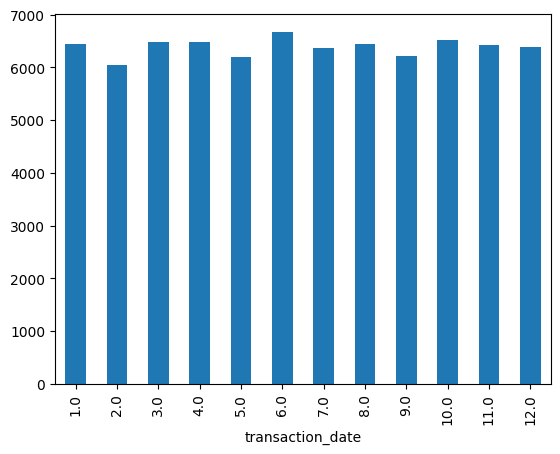

In [37]:
# Также реализуем график доходности по месяцам
df.groupby(df['transaction_date'].dt.month)['total'].sum().plot(kind='bar')

<Axes: xlabel='location'>

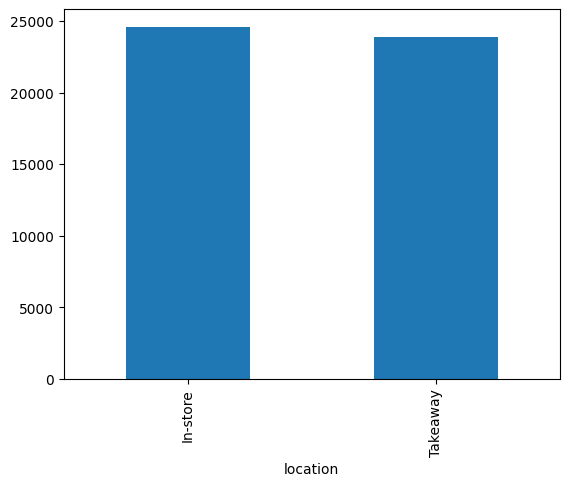

In [38]:
# Построим график по покупкам в различных магазинах.
df.groupby(df['location'])['total'].sum().plot(kind='bar')